In [1]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("tips")

# 사용할 컬럼
df = df[["total_bill", "tip", "size"]]

print(df.head())

   total_bill   tip  size
0       16.99  1.01     2
1       10.34  1.66     3
2       21.01  3.50     3
3       23.68  3.31     2
4       24.59  3.61     4


In [2]:
from sklearn.preprocessing import StandardScaler
x = df[["total_bill","tip","size"]]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)



In [3]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.5, min_samples=5)
df["cluster"] = model.fit_predict(x_scaled)

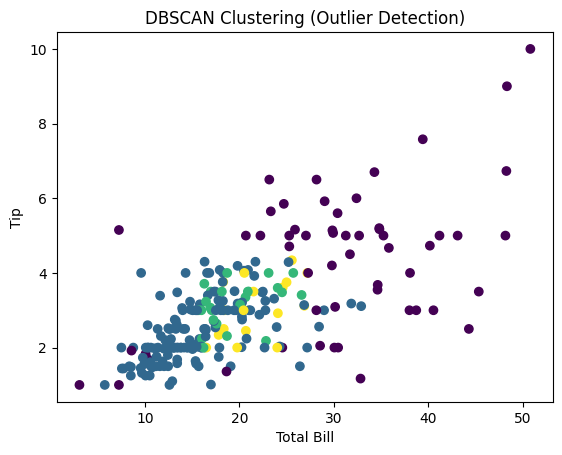

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df["total_bill"], df["tip"], c=df["cluster"])
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("DBSCAN Clustering (Outlier Detection)")
plt.show()

In [5]:
print(df["cluster"].value_counts())

cluster
 0    146
-1     56
 1     25
 2     17
Name: count, dtype: int64


In [6]:
print(df.groupby("cluster").mean(numeric_only=True))

# 분석

# 0 => 소규모 / 저가 소비 고객
# 1 => 중간규모 / 일반 소비 고객
# 2 => 대규모 / 고가 소비 고객
# -1 => 이상치 고객 => 이것만 모아서 따로 분석 가능

         total_bill       tip      size
cluster                                
-1        29.986071  4.316250  3.428571
 0        15.720000  2.462123  2.000000
 1        19.352000  3.124400  3.000000
 2        21.742941  3.075882  4.000000


In [7]:
import numpy as np
import pandas as pd

np.random.seed(42)

# 정상 거래 (300건)
normal = np.random.normal(
    loc=[50, 10],     # 평균 [금액, 횟수]
    scale=[10, 3],    # 표준편차
    size=(300, 2)
)

# 이상 거래 (20건)
fraud = np.random.normal(
    loc=[200, 40],
    scale=[20, 8],
    size=(20, 2)
)

# 합치기
data = np.vstack([
    normal,
    fraud
])

# DataFrame 생성
df = pd.DataFrame(
    data,
    columns=[
        "amount",     # 결제금액
        "count"       # 결제횟수
    ]
)

print(df.head())

# =================================

# 0 → 정상 거래 그룹
# 1 → 다른 거래 패턴
# -1 → 이상 거래(의심)

# 출력)
# 0     296
# 1      18
# -1      6

# ======================================
# 이상 거래만 보기

# 출력)
# | amount | count | cluster |
# |    220 |    52 |      -1 |
# |    240 |    60 |      -1 |


      amount      count
0  54.967142   9.585207
1  56.476885  14.569090
2  47.658466   9.297589
3  65.792128  12.302304
4  45.305256  11.627680


In [9]:
from sklearn.preprocessing import StandardScaler
x = df[["amount","count"]]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [10]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.5, min_samples=5)
df["cluster"] = model.fit_predict(x_scaled)

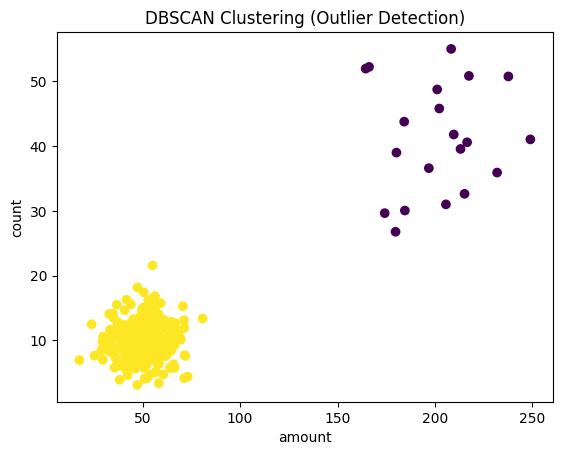

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df["amount"], df["count"], c=df["cluster"])
plt.xlabel("amount")
plt.ylabel("count")
plt.title("DBSCAN Clustering (Outlier Detection)")
plt.show()

In [12]:
print(df["cluster"].value_counts())

cluster
 0    300
-1     20
Name: count, dtype: int64


In [13]:
print(df.groupby("cluster").mean(numeric_only=True))

             amount      count
cluster                       
-1       201.879500  41.183834
 0        49.892157   9.951237
